In [ ]:
import polars as pl
import numpy as np
import os
from tqdm.auto import tqdm  
from datetime import datetime, timedelta
from collections import defaultdict
from scipy.optimize import curve_fit
import polars.selectors as cs
from functools import reduce
from sklearn.metrics import mean_absolute_error
import itertools



# Global varables
PARQUET_DIR = "mana_data/bar_data_parquet"
OUTPUT_DIR = "mana_data/propagator_model_data_cross_validation"
COLS = ["time","bid_price","ask_price","buy_vol","sell_vol","trade_volume", "unsided_vol"]

# Model parameters
WINDOW_DAYS = 21
DATE_FORMAT = "%Y%m%d"

In [ ]:
def get_mid_prices(df, bid_price_col="bid_price", ask_price_col="ask_price"):
    """ 
    Get the mid price series from the dataframe. Drop bars 
    where either side of the quote is missing; forward-fill 
    at most one bar.

    Args:
        df (pd.DataFrame): The dataframe containing the bid and ask prices.
        bid_price_col (str): The column name of the bid price.
        ask_price_col (str): The column name of the ask price.

    Returns:
        pd.Series: The mid price series.
    """
    mid_expr = ((pl.col(bid_price_col) + pl.col(ask_price_col)) / 2).forward_fill()
    return df.with_columns(mid_price=mid_expr)


def get_epsilons(
    df: pl.DataFrame,
    buy="buy_vol", sell="sell_vol",
    trade="trade_volume", unsided="unsided_vol",
    vol_col="sigma"                      # pre-computed vol per bar
) -> np.ndarray:
    """
    Returns ε_t = sign(q_t) * sigma_t * sqrt(|q_t| / V_t),
    or 0 if V_t == 0.

    Args:
        df (pl.DataFrame): The dataframe containing the buy, sell, trade, and unsided volumes.
        buy (str): The column name of the buy volume.
        sell (str): The column name of the sell volume.
        trade (str): The column name of the trade volume.
        unsided (str): The column name of the unsided volume.
        vol_col (str): The column name of the volatility.

    Returns:
        np.ndarray: The epsilon series.
    """
    # signed volume and total signed volume
    signed  = (pl.col(buy) - pl.col(sell))
    total   = (pl.col(trade) - pl.col(unsided))
    sigma   = pl.col(vol_col)

    # compute the magnitude √(|q|/V) * σ, then reapply the sign
    #eps_expr = (
    #    pl.when((total > 0) & (signed != 0) & (sigma > 0))
    #    .then((sigma * (signed.abs() / total).sqrt())  # magnitude
    #    * signed.sign()                         # re-apply sign safely
    #    )
    #    .otherwise(0.0)
    #    .fill_null(0.0)
    #    .alias("epsilon")
    #)

    # use bouchaud style epsilon which is the difference between buy and sell volume/ volume
    eps_expr = (
        pl.when((total > 0) & (signed != 0))
        .then((signed/ total))  # magnitude
        .otherwise(0.0)
        .fill_null(0.0)
        .alias("epsilon")
    )
    return df.with_columns(epsilon=eps_expr)

def get_intraday_volatility(df_window, window_size=10):
    # assume df_window has column 'mid' already
    df = df_window.with_columns(
        pl.col("mid_price")
        .rolling_std(window_size=window_size, min_samples=window_size)
        .fill_null(strategy="backward")
        .fill_null(strategy="forward")
        .cast(pl.Float64)
        .alias("sigma")
    )
    return df

def get_returns(df_window):
    """
    Get the returns series from the dataframe.
    """
    df = df_window.with_columns([
    (pl.col("mid_price").log() - pl.col("mid_price").shift(1).log())
    .fill_null(0.0)
    .alias("returns")
    ])
    return df


In [22]:
import warnings
from scipy.optimize import OptimizeWarning

# Suppress the warning, as we are taking steps to mitigate it
warnings.simplefilter("ignore", OptimizeWarning)

# --- Define MAX_LAG settings to test ---
MAX_LAGS_TO_TEST = [5, 10, 20, 30]
all_daily_params_dfs = []

# Loop over each MAX_LAG setting for calibration
for max_lag_val in tqdm(MAX_LAGS_TO_TEST, desc="Calibrating MAX_LAGs", position=0, leave=True):
    daily_params = defaultdict(dict)
    symbols = os.listdir(PARQUET_DIR)
    
    MAX_TAU = 180
    MIN_TAU = 0.5
    MIN_S = 1e-7

    # TODO: expand to full symbols
    for symbol in tqdm(symbols[0:20], desc="Processing symbols", position=1, leave=False):
        sym_in = os.path.join(PARQUET_DIR, symbol)
        sym_date_files = sorted(os.listdir(sym_in))
        sym_dates = [datetime.strptime(f.removeprefix("date="), DATE_FORMAT) for f in sym_date_files]
        sym_dates = sorted(sym_dates)

        for idx, current_date in enumerate(sym_dates):
            fn = f"date={current_date.strftime(DATE_FORMAT)}/data.parquet"
            path = os.path.join(sym_in, fn)
            try:
                df_window = pl.read_parquet(path, columns=COLS)
            except FileNotFoundError:
                continue

            if len(df_window) < max_lag_val + 1:
                continue
            df_window = df_window.sort("time")

            # Feature engineering...
            df_window = get_mid_prices(df_window)
            df_window = get_returns(df_window)
            df_window = get_intraday_volatility(df_window)
            df_window = get_epsilons(df_window)

            returns_i = df_window['returns'].to_numpy().astype(float)
            epsilon_i = df_window['epsilon'].to_numpy().astype(float)
            
            # Calibration logic...
            n = len(returns_i)
            S = np.array([np.dot(returns_i[k:], epsilon_i[:n-k]) / (n - k) for k in range(max_lag_val + 1)])
            
            E = S
            mask = E[1:] > MIN_S
            ys = np.log(E[1:][mask])
            ks = np.arange(max_lag_val + 1)[1:][mask]
            Es = E[1:][mask]
            Y_from_S0 = S[0] if not np.isnan(S[0]) else np.nan
            
            tau, tau_pos, tau_weighted = np.nan, np.nan, np.nan
            def exp_model(k, S0, tau_fit): return S0 * np.exp(-k / tau_fit)
            
            if len(ks) >= 4:
                weights = np.exp(-ks / 5)
                try:
                    m_weighted, _ = np.polyfit(ks, ys, 1, w=weights)
                    m, _ = np.polyfit(ks, ys, 1)
                    tau_weighted = -1.0 / m_weighted
                    tau = -1.0 / m

                    initial_tau_guess = abs(tau_weighted) if not np.isnan(tau_weighted) else max_lag_val
                    initial_tau_guess = max(MIN_TAU, min(initial_tau_guess, MAX_TAU))

                    popt, _ = curve_fit(exp_model, ks, Es, p0=[Es[0], initial_tau_guess], bounds=([0, MIN_TAU], [np.inf, MAX_TAU]), max_nfev=5000)
                    Y_from_S0 = popt[0]
                    tau_pos = popt[1]
                except (np.linalg.LinAlgError, RuntimeError):
                    pass

            # *** UPDATED LOGIC: Create a "long" format DataFrame ***
            # Instead of unique column names, we use a dedicated 'max_lag' column.
            df_out = pl.DataFrame({
                "tau": [float(tau)],
                "tau_pos": [float(tau_pos)],
                "tau_weighted": [float(tau_weighted)],
                "Y": [float(Y_from_S0)],
                "max_lag": [max_lag_val], # Add max_lag as a column
                "symbol": [symbol],
                "date": [current_date.strftime(DATE_FORMAT)]
            })

            daily_params.setdefault(symbol, {})[current_date.strftime(DATE_FORMAT)] = df_out
    
    # Consolidate results for the current max_lag_val
    df_lag_all = pl.concat(
        [df for sym_data in daily_params.values() for df in sym_data.values()],
        rechunk=True
    )
    all_daily_params_dfs.append(df_lag_all)

# --- NEW: Combine all dataframes vertically using pl.concat ---
# This is much simpler and more robust than the reduce(join) method.
df_all = pl.concat(all_daily_params_dfs, how="vertical")

df_all = df_all.with_columns(
    pl.col("date").str.strptime(pl.Date, DATE_FORMAT)
).sort(["symbol", "date", "max_lag"])

print("\nVertically concatenated DataFrame with 'max_lag' as a column:")
print(df_all.head())

Calibrating MAX_LAGs:   0%|          | 0/4 [00:00<?, ?it/s]

Processing symbols:   0%|          | 0/20 [00:00<?, ?it/s]

Processing symbols:   0%|          | 0/20 [00:00<?, ?it/s]

Processing symbols:   0%|          | 0/20 [00:00<?, ?it/s]

Processing symbols:   0%|          | 0/20 [00:00<?, ?it/s]


Vertically concatenated DataFrame with 'max_lag' as a column:
shape: (5, 7)
┌───────────┬────────────┬──────────────┬──────────┬─────────┬─────────┬────────────┐
│ tau       ┆ tau_pos    ┆ tau_weighted ┆ Y        ┆ max_lag ┆ symbol  ┆ date       │
│ ---       ┆ ---        ┆ ---          ┆ ---      ┆ ---     ┆ ---     ┆ ---        │
│ f64       ┆ f64        ┆ f64          ┆ f64      ┆ i64     ┆ str     ┆ date       │
╞═══════════╪════════════╪══════════════╪══════════╪═════════╪═════════╪════════════╡
│ NaN       ┆ NaN        ┆ NaN          ┆ 0.000278 ┆ 5       ┆ sym=ATO ┆ 2022-01-03 │
│ NaN       ┆ NaN        ┆ NaN          ┆ 0.000278 ┆ 10      ┆ sym=ATO ┆ 2022-01-03 │
│ 68.042903 ┆ 58.865123  ┆ 4.297435     ┆ 0.000028 ┆ 20      ┆ sym=ATO ┆ 2022-01-03 │
│ 84.894357 ┆ 19.500535  ┆ 4.376207     ┆ 0.00004  ┆ 30      ┆ sym=ATO ┆ 2022-01-03 │
│ -2.925846 ┆ 179.998069 ┆ -2.617875    ┆ 0.000015 ┆ 5       ┆ sym=ATO ┆ 2022-01-04 │
└───────────┴────────────┴──────────────┴──────────┴─────────┴─

In [23]:
# The input df_all is already in long format with a 'max_lag' column

# List of parameter columns to apply rolling medians to
param_cols_to_smooth = ["Y", "tau", "tau_pos", "tau_weighted"]

# --- Dynamically create rolling median expressions ---
rolling_exprs = []
window_sizes = [WINDOW_DAYS, int(WINDOW_DAYS * 1.5), int(WINDOW_DAYS * 2), int(WINDOW_DAYS * 3)]

for col_name in param_cols_to_smooth:
    # Use fill_nan(None) to convert NaNs to nulls for Polars
    base_col = pl.col(col_name).fill_nan(None)
    for window in window_sizes:
        rolling_exprs.append(
            base_col
            # The .over() clause is key: it calculates the rolling median within each symbol AND max_lag group
            .rolling_median(window_size=window, min_samples=1, center=True)
            .over(["symbol", "max_lag"])
            .alias(f"{col_name}_median_{window}")
        )

# --- Apply all expressions to the DataFrame ---
df_rolling = df_all.with_columns(rolling_exprs)

print("Long-format DataFrame with all rolling parameters generated:")
print(df_rolling.head())

Long-format DataFrame with all rolling parameters generated:
shape: (5, 23)
┌───────────┬───────────┬───────────┬──────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ tau       ┆ tau_pos   ┆ tau_weigh ┆ Y        ┆ … ┆ tau_weigh ┆ tau_weigh ┆ tau_weigh ┆ tau_weigh │
│ ---       ┆ ---       ┆ ted       ┆ ---      ┆   ┆ ted_media ┆ ted_media ┆ ted_media ┆ ted_media │
│ f64       ┆ f64       ┆ ---       ┆ f64      ┆   ┆ n_21      ┆ n_31      ┆ n_42      ┆ n_63      │
│           ┆           ┆ f64       ┆          ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│           ┆           ┆           ┆          ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
╞═══════════╪═══════════╪═══════════╪══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ NaN       ┆ NaN       ┆ NaN       ┆ 0.000278 ┆ … ┆ 2.930971  ┆ 5.61204   ┆ 4.801352  ┆ 4.801352  │
│ NaN       ┆ NaN       ┆ NaN       ┆ 0.000278 ┆ … ┆ 4.991559  ┆ 4.682629  ┆ 4.682629  ┆ 4.669809  │
│ 68.042903 ┆ 5

/var/folders/mn/sstp0slh8xjckg0059bj70p80000gp/T/ipykernel_37391/534232165.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


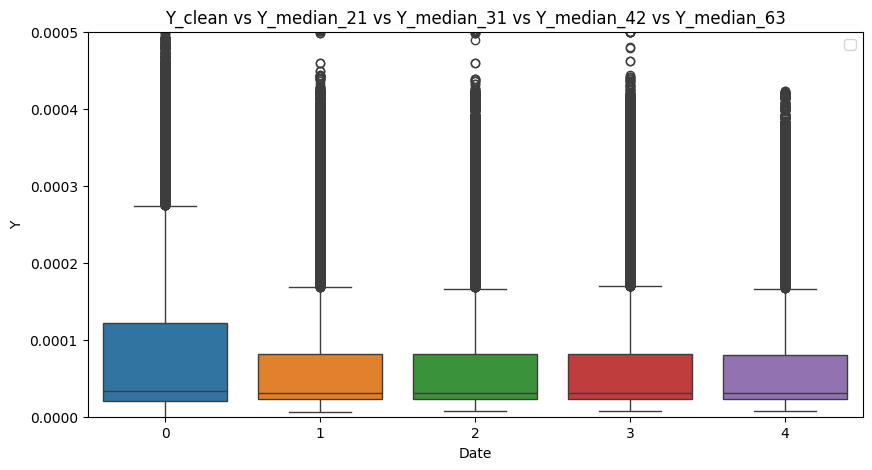

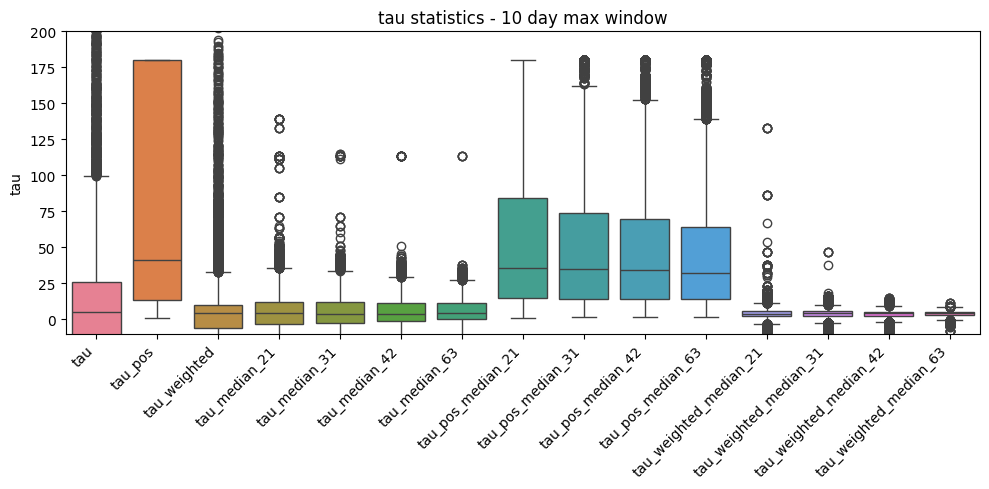

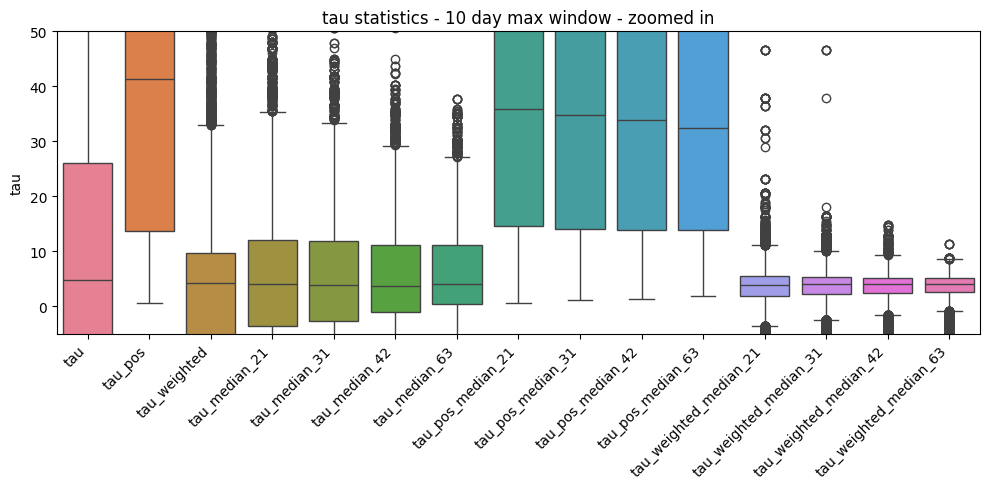

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# remove first WINDOW_DAYS days from the data to discard warm-up data which may be noisy
#df_rolling = df_rolling.filter(pl.col("date") > pl.col("date").min() + timedelta(days=WINDOW_DAYS))


# plot rangets of Y_clean, Y_ewm, tau_clean, tau_ewm
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_rolling[["Y", "Y_median_21", "Y_median_31", "Y_median_42", "Y_median_63"]])
plt.xlabel("Date")
plt.ylabel("Y")
plt.ylim(0, 0.0005)
plt.title("Y_clean vs Y_median_21 vs Y_median_31 vs Y_median_42 vs Y_median_63")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
# plot as box plots loop through all tau columns
titles = [col for col in df_rolling.columns if "tau" in col]
ax = sns.boxplot(data=df_rolling[titles])
positions = list(range(len(titles)))
ax.set_xticks(positions)

# Then set the rotated labels
ax.set_xticklabels(titles, rotation=45, ha='right')
plt.ylabel("tau")
plt.ylim(-10, 200)
plt.title("tau statistics - 10 day max window")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
# plot as box plots loop through all tau columns
titles = [col for col in df_rolling.columns if "tau" in col]
ax = sns.boxplot(data=df_rolling[titles])
positions = list(range(len(titles)))
ax.set_xticks(positions)

# Then set the rotated labels
ax.set_xticklabels(titles, rotation=45, ha='right')
plt.ylabel("tau")
plt.ylim(-5, 50)
plt.title("tau statistics - 10 day max window - zoomed in")
plt.tight_layout()
plt.show()

shape: (18, 15)
┌──────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ symbol   ┆ tau_pos_p ┆ tau_weigh ┆ tau_media ┆ … ┆ tau_weigh ┆ tau_weigh ┆ tau_weigh ┆ tau_weigh │
│ ---      ┆ erc_neg   ┆ ted_perc_ ┆ n_21_perc ┆   ┆ ted_media ┆ ted_media ┆ ted_media ┆ ted_media │
│ str      ┆ ---       ┆ neg       ┆ _neg      ┆   ┆ n_21_perc ┆ n_31_perc ┆ n_42_perc ┆ n_63_perc │
│          ┆ f64       ┆ ---       ┆ ---       ┆   ┆ _ne…      ┆ _ne…      ┆ _ne…      ┆ _ne…      │
│          ┆           ┆ f64       ┆ f64       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│          ┆           ┆           ┆           ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
╞══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ sym=ATO  ┆ 0.0       ┆ 0.331933  ┆ 0.320378  ┆ … ┆ 0.309874  ┆ 0.273109  ┆ 0.213235  ┆ 0.201681  │
│ sym=BKNG ┆ 0.0       ┆ 0.218487  ┆ 0.194328  ┆ … ┆ 0.078782  ┆ 0.033613  

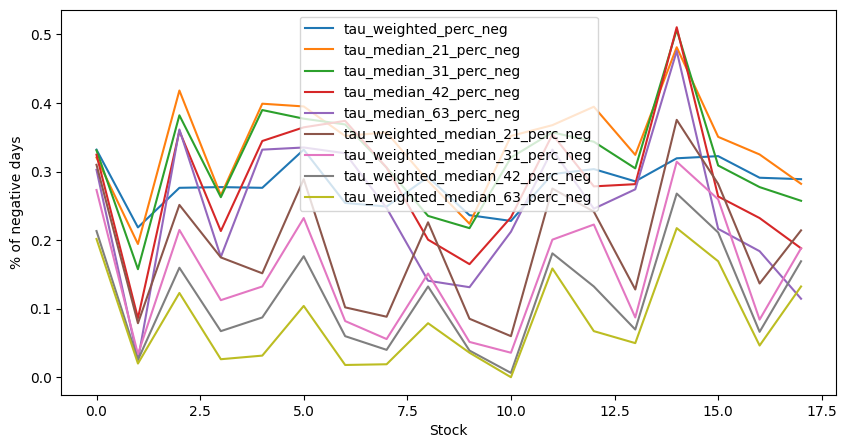

shape: (238, 15)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ date      ┆ tau_pos_p ┆ tau_weigh ┆ tau_media ┆ … ┆ tau_weigh ┆ tau_weigh ┆ tau_weigh ┆ tau_weig │
│ ---       ┆ erc_neg   ┆ ted_perc_ ┆ n_21_perc ┆   ┆ ted_media ┆ ted_media ┆ ted_media ┆ hted_med │
│ date      ┆ ---       ┆ neg       ┆ _neg      ┆   ┆ n_21_perc ┆ n_31_perc ┆ n_42_perc ┆ ian_63_p │
│           ┆ f64       ┆ ---       ┆ ---       ┆   ┆ _ne…      ┆ _ne…      ┆ _ne…      ┆ erc_ne…  │
│           ┆           ┆ f64       ┆ f64       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│           ┆           ┆           ┆           ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 2022-06-0 ┆ 0.0       ┆ 0.25      ┆ 0.450704  ┆ … ┆ 0.239437  ┆ 0.152778  ┆ 0.166667  ┆ 0.027778 │
│ 7         ┆           ┆           ┆           ┆   ┆           ┆         

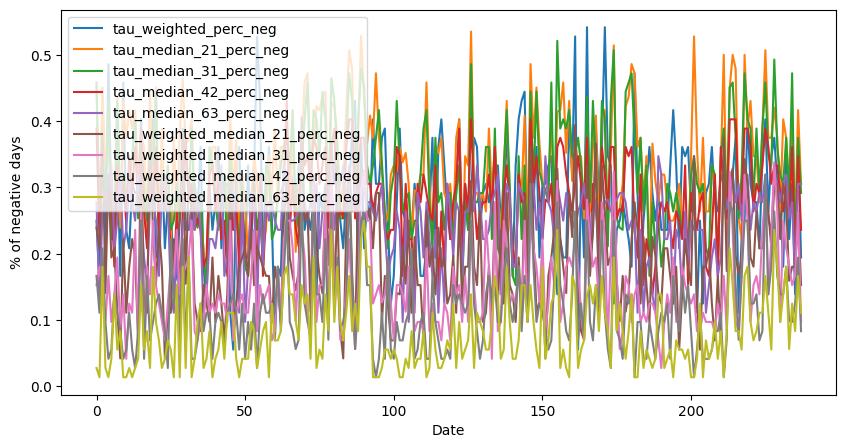

In [31]:

# calculate for each tau column by % of negative days by stock
perc_neg = (
    df_rolling
    .group_by("symbol")
    .agg([
        (pl.col(col).lt(0).mean()).alias(f"{col}_perc_neg")
        for col in df_rolling.select(cs.starts_with("tau_")).columns
    ])
)
perc_neg.sort(f"tau_median_63_perc_neg", descending=True)
print(perc_neg)

# plot the % of negative days for each tau column
plt.figure(figsize=(10, 5))
columns = [col for col in perc_neg.columns if "perc_neg" in col]
# remove _pos_ in column name
columns = [col for col in columns if "_pos_" not in col]
for col in columns:
  plt.plot(perc_neg[col], label=col)
plt.legend()
plt.xlabel("Stock")
plt.ylabel("% of negative days")
plt.show()


# plot the % of negative stocks by day
perc_neg_day = (
    df_rolling
    .group_by("date")
    .agg([
        (pl.col(col).lt(0).mean()).alias(f"{col}_perc_neg")
        for col in df_rolling.select(cs.starts_with("tau_")).columns
    ])
)

print(perc_neg_day)

# plot by day
plt.figure(figsize=(10, 5))
columns = [col for col in perc_neg_day.columns if "perc_neg" in col]
# remove _pos_ in column name
columns = [col for col in columns if "_pos_" not in col]
for col in columns:
  plt.plot(perc_neg_day[col], label=col)
plt.legend()
plt.xlabel("Date")
plt.ylabel("% of negative days")
plt.show()


In [ ]:

# --- Prediction Function using Vectorization ---
def get_predictions_vectorized(df_day: pl.DataFrame, Y: float, tau: float, max_lag: int) -> np.ndarray:
    """
    Generates predicted returns using a fast numpy convolution.

    Args:   
        df_day: Polars DataFrame containing the day's data
        Y: The Y parameter value
        tau: The tau parameter value
        max_lag: The maximum lag to use in the prediction

    Returns:
        np.ndarray: The predicted returns
    """
    if "epsilon" not in df_day.columns:
        df_day = get_epsilons(df_day)

    epsilon_series = df_day['epsilon'].to_numpy()
    n_obs = len(epsilon_series)

    # Handle cases with insufficient data
    if n_obs < max_lag:
        return np.zeros(n_obs)

    # Construct the propagator G(k)
    lags = np.arange(1, max_lag + 1)
    G = Y * np.exp(-lags / tau)

    # Use np.convolve for a massive speedup. 'valid' mode is equivalent to the inner loop.
    # We must reverse the propagator G for the dot product to be correct in convolution.
    valid_predictions = np.convolve(epsilon_series, G[::-1], mode='valid')
    valid_predictions = valid_predictions[:n_obs - max_lag]

    # Pad the start with zeros to match the original output shape
    padding = np.zeros(max_lag)
    
    return np.concatenate([padding, valid_predictions])

In [ ]:
import itertools
from sklearn.metrics import mean_absolute_error
from collections import defaultdict

# --- Identify all parameter columns and create the grid ---
y_param_cols = sorted([col for col in df_rolling.columns if col.startswith("Y_") and "median" in col])
tau_param_cols = sorted([col for col in df_rolling.columns if col.startswith("tau_") and "median" in col])
max_lag_values = df_rolling['max_lag'].unique().to_list()

param_grid = list(itertools.product(y_param_cols, tau_param_cols, max_lag_values))
print(f"Created parameter grid with {len(param_grid)} combinations to test per stock.")

# --- Configuration ---
TRAIN_WINDOW_DAYS = 63
TEST_WINDOW_DAYS = 21

# --- Stock-by-Stock Cross-Validation (Optimized) ---
best_params_per_stock = []
all_fold_results = []
symbols = df_rolling['symbol'].unique().to_list()

for symbol in tqdm(symbols, desc="Finding Best Params per Symbol"):
    
    try:
        sym_in_dir = os.path.join(PARQUET_DIR, symbol)
        date_files = sorted(os.listdir(sym_in_dir))


        # Only load files needed for the date range of this stock's parameters
        df_sym_params_all_lags = df_rolling.filter(pl.col("symbol") == symbol)
        min_date_needed = df_sym_params_all_lags['date'].min()
        
        # Filter date_files before reading to reduce I/O
        relevant_date_files = [f for f in date_files if datetime.strptime(f.removeprefix("date="), DATE_FORMAT).date() >= min_date_needed]
        
        daily_dfs = [pl.read_parquet(os.path.join(sym_in_dir, f, "data.parquet")).with_columns(date=pl.lit(datetime.strptime(f.removeprefix("date="), DATE_FORMAT).date())) for f in relevant_date_files]
        if not daily_dfs: continue
        df_sym_full = pl.concat(daily_dfs).sort("time")
        df_sym_full = df_sym_full.pipe(get_mid_prices).pipe(get_returns).pipe(get_epsilons)

    except (FileNotFoundError, pl.exceptions.NoDataError):
        continue

    all_dates = sorted(df_sym_params_all_lags['date'].unique().to_list())
    
    # A parameter set is only valid if both Y and tau are always positive.
    valid_param_grid = []
    for y_col, tau_col, max_lag in param_grid:
        # Check if the Y and tau columns for this combo have any nulls or non-positives
        is_y_valid = not df_sym_params_all_lags.filter(pl.col("max_lag") == max_lag)[y_col].is_null().any() and \
                     (df_sym_params_all_lags.filter(pl.col("max_lag") == max_lag)[y_col] > 0).all()
        is_tau_valid = not df_sym_params_all_lags.filter(pl.col("max_lag") == max_lag)[tau_col].is_null().any() and \
                       (df_sym_params_all_lags.filter(pl.col("max_lag") == max_lag)[tau_col] > 0).all()

        if is_y_valid and is_tau_valid:
            valid_param_grid.append((y_col, tau_col, max_lag))

    if not valid_param_grid:
        print(f"Warning: No consistently positive parameter sets found for {symbol}. Skipping.")
        continue

    results_tracker = defaultdict(lambda: defaultdict(list))

    # This is now the main progress bar to watch for each symbol
    time_window_iterator = tqdm(
        range(len(all_dates) - (TRAIN_WINDOW_DAYS + TEST_WINDOW_DAYS) + 1),
        desc=f"CV Folds for {symbol}",
        leave=False
    )
    for i in time_window_iterator:
        train_start_date = all_dates[i]
        train_end_date = all_dates[i + TRAIN_WINDOW_DAYS - 1]
        test_start_date = all_dates[i + TRAIN_WINDOW_DAYS]
        test_end_date = all_dates[i + TRAIN_WINDOW_DAYS + TEST_WINDOW_DAYS - 1]

        df_train = df_sym_full.filter((pl.col("date") >= train_start_date) & (pl.col("date") <= train_end_date))
        df_test = df_sym_full.filter((pl.col("date") >= test_start_date) & (pl.col("date") <= test_end_date))

        if df_test.is_empty() or df_train.is_empty():
            continue
        
        mean_train_return = df_train['returns'].mean()
        
        for y_col, tau_col, max_lag in valid_param_grid:
 
            params_row = df_sym_params_all_lags.filter(
                (pl.col("date") == train_end_date) & (pl.col("max_lag") == max_lag)
            )
            if params_row.is_empty(): continue
            
            Y_train, tau_train = params_row.get_column(y_col)[0], params_row.get_column(tau_col)[0]
            
            predictions = get_predictions_vectorized(df_test, Y_train, tau_train, max_lag)
            eval_preds = predictions[max_lag:]; eval_actuals = df_test['returns'].to_numpy()[max_lag:]
            if len(eval_actuals) == 0: continue

            mae = mean_absolute_error(eval_actuals, eval_preds)
            ss_res = np.sum((eval_actuals - eval_preds)**2)
            ss_tot = np.sum((eval_actuals - mean_train_return)**2)
            r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
            
            key = (y_col, tau_col, max_lag)
            results_tracker[key]['r2'].append(r2)
            results_tracker[key]['mae'].append(mae)

            all_fold_results.append({
                "symbol": symbol, "test_end_date": test_end_date,
                "y_param": y_col, "tau_param": tau_col, "max_lag": max_lag,
                "r2": r2, "mae": mae
            })

        if results_tracker:
            final_results = [
            {
                "Y_best_col": params[0],
                "tau_best_col": params[1],
                "max_lag_best": params[2],
                "mean_r2": np.mean(metrics['r2']),
                "mean_mae": np.mean(metrics['mae'])
            }
            for params, metrics in results_tracker.items()
            ]

            df_sym_results = pl.DataFrame(final_results)

            # Find the parameter set with the highest mean R²
            best_run = df_sym_results.sort("mean_r2", descending=True).row(0, named=True)
    
            best_params_per_stock.append({
                "symbol": symbol,
                **best_run
            })

# --- Final DataFrame with Best Parameters ---
df_best_params = pl.DataFrame(best_params_per_stock)

# --- Join the best param names back to the main rolling dataframe ---
final_df = df_rolling.join(df_best_params, on="symbol", how="left")


Created parameter grid with 192 combinations to test per stock.


Finding Best Params per Symbol: 100%|██████████| 18/18 [02:04<00:00,  6.94s/it]


In [90]:
# --- Create the Final, Clean DataFrame for RL Loader and Plotting ---

print("\n--- Best Parameter Set Found per Stock ---")
print(df_best_params.sort("mean_r2", descending=True).head())

# This will hold the final results for all stocks
final_results_list = []

for row in tqdm(df_best_params.iter_rows(named=True), desc="Building Final Dataset", total=len(df_best_params)):
    # Get the best column names and lag for this specific stock
    symbol = row['symbol']
    y_col = row['Y_best_col']
    tau_col = row['tau_best_col']
    max_lag = row['max_lag_best']
    
    # Filter the rolling data to get the daily values for this stock's best parameters
    df_stock_best_daily = df_rolling.filter(
        (pl.col("symbol") == symbol) & (pl.col("max_lag") == max_lag)
    ).select(
        "symbol",
        "date",
        pl.col(y_col).alias("Y_best"),          # Rename to the final, clean name
        pl.col(tau_col).alias("tau_best"),      # Rename to the final, clean name
        pl.lit(max_lag).alias("max_lag_best")   # Add the best lag as a constant column
    )
    
    final_results_list.append(df_stock_best_daily)

# Concatenate all the results into a single, clean DataFrame
# The positivity filter is no longer needed here because we fixed it in the CV loop
df_final_for_rl = pl.concat(final_results_list).drop_nulls()

print("\n--- Final, Clean DataFrame Ready for RL Loader and Plotting ---")
print(df_final_for_rl.head())


--- Best Parameter Set Found per Stock ---
shape: (5, 6)
┌──────────┬─────────────┬────────────────────────┬──────────────┬──────────┬──────────┐
│ symbol   ┆ Y_best_col  ┆ tau_best_col           ┆ max_lag_best ┆ mean_r2  ┆ mean_mae │
│ ---      ┆ ---         ┆ ---                    ┆ ---          ┆ ---      ┆ ---      │
│ str      ┆ str         ┆ str                    ┆ i64          ┆ f64      ┆ f64      │
╞══════════╪═════════════╪════════════════════════╪══════════════╪══════════╪══════════╡
│ sym=CPRT ┆ Y_median_21 ┆ tau_weighted_median_63 ┆ 20           ┆ 0.418173 ┆ 0.014714 │
│ sym=CPRT ┆ Y_median_63 ┆ tau_weighted_median_63 ┆ 20           ┆ 0.178637 ┆ 0.014706 │
│ sym=SWKS ┆ Y_median_63 ┆ tau_pos_median_31      ┆ 20           ┆ 0.121867 ┆ 0.022546 │
│ sym=ATO  ┆ Y_median_21 ┆ tau_pos_median_21      ┆ 10           ┆ 0.099622 ┆ 0.009709 │
│ sym=ATO  ┆ Y_median_21 ┆ tau_pos_median_21      ┆ 10           ┆ 0.098957 ┆ 0.009644 │
└──────────┴─────────────┴────────────────────────┴─

Building Final Dataset: 100%|██████████| 2790/2790 [00:01<00:00, 2036.48it/s]



--- Final, Clean DataFrame Ready for RL Loader and Plotting ---
shape: (5, 5)
┌─────────┬────────────┬──────────┬───────────┬──────────────┐
│ symbol  ┆ date       ┆ Y_best   ┆ tau_best  ┆ max_lag_best │
│ ---     ┆ ---        ┆ ---      ┆ ---       ┆ ---          │
│ str     ┆ date       ┆ f64      ┆ f64       ┆ i32          │
╞═════════╪════════════╪══════════╪═══════════╪══════════════╡
│ sym=ITW ┆ 2022-01-03 ┆ 0.00002  ┆ 56.987798 ┆ 30           │
│ sym=ITW ┆ 2022-01-04 ┆ 0.00002  ┆ 56.420842 ┆ 30           │
│ sym=ITW ┆ 2022-01-05 ┆ 0.00002  ┆ 53.312207 ┆ 30           │
│ sym=ITW ┆ 2022-01-06 ┆ 0.000021 ┆ 50.203572 ┆ 30           │
│ sym=ITW ┆ 2022-01-07 ┆ 0.000022 ┆ 53.312207 ┆ 30           │
└─────────┴────────────┴──────────┴───────────┴──────────────┘


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Create DataFrames from the results of the previous cell ---
df_all_folds = pl.DataFrame(all_fold_results)

# --- Plot 1: Performance Over Time (Efficiently) ---

# Join the fold-by-fold results with the table of best parameters
df_perf_with_best_names = df_all_folds.join(
    df_best_params.select(["symbol", "Y_best_col", "tau_best_col", "max_lag_best"]), 
    on="symbol"
)

# Filter for the rows that correspond to the best model for each stock
df_daily_perf = df_perf_with_best_names.filter(
    (pl.col("y_param") == pl.col("Y_best_col")) &
    (pl.col("tau_param") == pl.col("tau_best_col")) &
    (pl.col("max_lag") == pl.col("max_lag_best"))
)

# Aggregate daily results across all stocks for the plot
df_time_perf = df_daily_perf.group_by("test_end_date").agg([
    pl.mean("r2").alias("mean_r2"),
    pl.mean("mae").alias("mean_mae")
]).sort("test_end_date")

# Create the time-series plot
fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(df_time_perf["test_end_date"], df_time_perf["mean_r2"], 'b-', label='Mean R²')
ax1.set_xlabel('Date'); ax1.set_ylabel('Mean R²', color='b'); ax1.tick_params('y', colors='b')
ax1.axhline(0, color='gray', linestyle='--'); ax1.set_title('Performance of Best Models Over Time')
ax2 = ax1.twinx()
ax2.plot(df_time_perf["test_end_date"], df_time_perf["mean_mae"], 'r-', label='Mean MAE')
ax2.set_ylabel('Mean MAE', color='r'); ax2.tick_params('y', colors='r')
fig.tight_layout(); plt.show()

# --- Plot 2: Performance Distribution by Stock ---
# This plot uses df_best_params directly, as before.
df_stock_perf = df_best_params.sort("mean_r2", descending=True)
print("\nTop 50 performing stocks by R²:"); print(df_stock_perf.head(50))
print("\nBottom 50 performing stocks by R²:"); print(df_stock_perf.tail(50))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
sns.boxplot(y=df_stock_perf["mean_r2"], ax=ax1)
ax1.set_title('Distribution of Best Mean R² Across Stocks'); ax1.axhline(0, color='gray', linestyle='--'); ax1.set_ylabel("Mean R²")
sns.boxplot(y=df_stock_perf["mean_mae"], ax=ax2)
ax2.set_title('Distribution of Best Mean MAE Across Stocks'); ax2.set_ylabel("Mean MAE")
plt.tight_layout(); plt.show()

ColumnNotFoundError: unable to find column "symbol"; valid columns: []

In [ ]:
# --- Save the Optimized Parameters for the RL Loader ---

# Define the root directory where the data will be saved
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Saving daily parameters to: {OUTPUT_DIR}")

# Group the final DataFrame by symbol and date to write individual files
for (symbol, single_date), df_group in tqdm(df_final_for_rl.group_by(["symbol", "date"]), desc="Saving Files"):
    
    # Format the date and create the directory structure
    date_str = single_date.strftime('%Y%m%d')
    symbol_dir = os.path.join(OUTPUT_DIR, f"sym={symbol}")
    final_dir = os.path.join(symbol_dir, f"date={date_str}")
    os.makedirs(final_dir, exist_ok=True)
    
    # Define the final file path
    file_path = os.path.join(final_dir, "daily_params.parquet")
    
    # Write the single-row DataFrame for that day to a parquet file
    # We rename the columns to match what your loader expects, if needed, or save as is.
    # Assuming your loader will be updated to look for 'Y_best' and 'tau_best'.
    df_group.write_parquet(file_path)

print("\n--- Data saving complete. ---")
print(f"Your RL environment can now use the PropagatorParamLoader with the directory '{OUTPUT_DIR}'.")

Saving daily parameters to: mana_data/propagator_model_data_cross_validation


Saving Files: 101it [00:00, 1007.55it/s]

shape: (5, 5)
┌────────┬────────────┬─────────┬────────────┬──────────────┐
│ symbol ┆ date       ┆ Y_best  ┆ tau_best   ┆ max_lag_best │
│ ---    ┆ ---        ┆ ---     ┆ ---        ┆ ---          │
│ str    ┆ date       ┆ f64     ┆ f64        ┆ i32          │
╞════════╪════════════╪═════════╪════════════╪══════════════╡
│ sym=EA ┆ 2022-02-23 ┆ 0.00002 ┆ 154.915854 ┆ 30           │
│ sym=EA ┆ 2022-02-23 ┆ 0.00002 ┆ 154.915854 ┆ 30           │
│ sym=EA ┆ 2022-02-23 ┆ 0.00002 ┆ 154.915854 ┆ 30           │
│ sym=EA ┆ 2022-02-23 ┆ 0.00002 ┆ 131.222773 ┆ 30           │
│ sym=EA ┆ 2022-02-23 ┆ 0.00002 ┆ 131.222773 ┆ 30           │
└────────┴────────────┴─────────┴────────────┴──────────────┘
shape: (5, 5)
┌─────────┬────────────┬──────────┬───────────┬──────────────┐
│ symbol  ┆ date       ┆ Y_best   ┆ tau_best  ┆ max_lag_best │
│ ---     ┆ ---        ┆ ---      ┆ ---       ┆ ---          │
│ str     ┆ date       ┆ f64      ┆ f64       ┆ i32          │
╞═════════╪════════════╪══════════╪═══

Saving Files: 255it [00:00, 1315.13it/s]

shape: (5, 5)
┌─────────┬────────────┬──────────┬───────────┬──────────────┐
│ symbol  ┆ date       ┆ Y_best   ┆ tau_best  ┆ max_lag_best │
│ ---     ┆ ---        ┆ ---      ┆ ---       ┆ ---          │
│ str     ┆ date       ┆ f64      ┆ f64       ┆ i32          │
╞═════════╪════════════╪══════════╪═══════════╪══════════════╡
│ sym=ATO ┆ 2022-11-17 ┆ 0.000026 ┆ 75.687998 ┆ 20           │
│ sym=ATO ┆ 2022-11-17 ┆ 0.000029 ┆ 75.687998 ┆ 20           │
│ sym=ATO ┆ 2022-11-17 ┆ 0.000029 ┆ 75.687998 ┆ 20           │
│ sym=ATO ┆ 2022-11-17 ┆ 0.000045 ┆ 13.32033  ┆ 10           │
│ sym=ATO ┆ 2022-11-17 ┆ 0.000045 ┆ 13.32033  ┆ 10           │
└─────────┴────────────┴──────────┴───────────┴──────────────┘
shape: (5, 5)
┌────────┬────────────┬──────────┬──────────┬──────────────┐
│ symbol ┆ date       ┆ Y_best   ┆ tau_best ┆ max_lag_best │
│ ---    ┆ ---        ┆ ---      ┆ ---      ┆ ---          │
│ str    ┆ date       ┆ f64      ┆ f64      ┆ i32          │
╞════════╪════════════╪══════════╪═

...

shape: (5, 5)
┌─────────┬────────────┬──────────┬──────────┬──────────────┐
│ symbol  ┆ date       ┆ Y_best   ┆ tau_best ┆ max_lag_best │
│ ---     ┆ ---        ┆ ---      ┆ ---      ┆ ---          │
│ str     ┆ date       ┆ f64      ┆ f64      ┆ i32          │
╞═════════╪════════════╪══════════╪══════════╪══════════════╡
│ sym=BKR ┆ 2022-08-10 ┆ 0.00002  ┆ 5.058049 ┆ 20           │
│ sym=BKR ┆ 2022-08-10 ┆ 0.000021 ┆ 5.058049 ┆ 20           │
│ sym=BKR ┆ 2022-08-10 ┆ 0.000021 ┆ 5.058049 ┆ 20           │
│ sym=BKR ┆ 2022-08-10 ┆ 0.000021 ┆ 5.058049 ┆ 20           │
│ sym=BKR ┆ 2022-08-10 ┆ 0.000021 ┆ 5.058049 ┆ 20           │
└─────────┴────────────┴──────────┴──────────┴──────────────┘
shape: (5, 5)
┌─────────┬────────────┬──────────┬───────────┬──────────────┐
│ symbol  ┆ date       ┆ Y_best   ┆ tau_best  ┆ max_lag_best │
│ ---     ┆ ---        ┆ ---      ┆ ---       ┆ ---          │
│ str     ┆ date       ┆ f64      ┆ f64       ┆ i32          │
╞═════════╪════════════╪══════════╪═══

Saving Files: 4150it [00:03, 1138.25it/s]

shape: (5, 5)
┌────────┬────────────┬──────────┬────────────┬──────────────┐
│ symbol ┆ date       ┆ Y_best   ┆ tau_best   ┆ max_lag_best │
│ ---    ┆ ---        ┆ ---      ┆ ---        ┆ ---          │
│ str    ┆ date       ┆ f64      ┆ f64        ┆ i32          │
╞════════╪════════════╪══════════╪════════════╪══════════════╡
│ sym=ES ┆ 2022-01-06 ┆ 0.000247 ┆ 179.659724 ┆ 5            │
│ sym=ES ┆ 2022-01-06 ┆ 0.000247 ┆ 179.659724 ┆ 5            │
│ sym=ES ┆ 2022-01-06 ┆ 0.000247 ┆ 179.659724 ┆ 5            │
│ sym=ES ┆ 2022-01-06 ┆ 0.000248 ┆ 179.659724 ┆ 5            │
│ sym=ES ┆ 2022-01-06 ┆ 0.000248 ┆ 179.659724 ┆ 5            │
└────────┴────────────┴──────────┴────────────┴──────────────┘
shape: (5, 5)
┌─────────┬────────────┬──────────┬───────────┬──────────────┐
│ symbol  ┆ date       ┆ Y_best   ┆ tau_best  ┆ max_lag_best │
│ ---     ┆ ---        ┆ ---      ┆ ---       ┆ ---          │
│ str     ┆ date       ┆ f64      ┆ f64       ┆ i32          │
╞═════════╪════════════╪═══

Saving Files: 4284it [00:03, 1257.95it/s]

shape: (5, 5)
┌─────────┬────────────┬──────────┬──────────┬──────────────┐
│ symbol  ┆ date       ┆ Y_best   ┆ tau_best ┆ max_lag_best │
│ ---     ┆ ---        ┆ ---      ┆ ---      ┆ ---          │
│ str     ┆ date       ┆ f64      ┆ f64      ┆ i32          │
╞═════════╪════════════╪══════════╪══════════╪══════════════╡
│ sym=BKR ┆ 2022-07-06 ┆ 0.000026 ┆ 6.015941 ┆ 20           │
│ sym=BKR ┆ 2022-07-06 ┆ 0.000021 ┆ 6.015941 ┆ 20           │
│ sym=BKR ┆ 2022-07-06 ┆ 0.000021 ┆ 6.015941 ┆ 20           │
│ sym=BKR ┆ 2022-07-06 ┆ 0.000021 ┆ 6.015941 ┆ 20           │
│ sym=BKR ┆ 2022-07-06 ┆ 0.000021 ┆ 6.015941 ┆ 20           │
└─────────┴────────────┴──────────┴──────────┴──────────────┘
shape: (5, 5)
┌────────┬────────────┬──────────┬──────────┬──────────────┐
│ symbol ┆ date       ┆ Y_best   ┆ tau_best ┆ max_lag_best │
│ ---    ┆ ---        ┆ ---      ┆ ---      ┆ ---          │
│ str    ┆ date       ┆ f64      ┆ f64      ┆ i32          │
╞════════╪════════════╪══════════╪══════════╪═